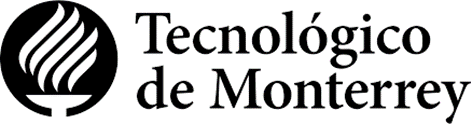 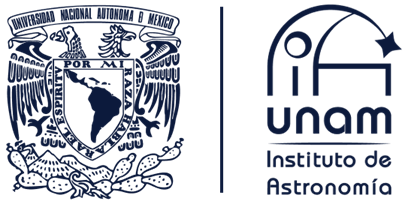


# **Proyecto Integrador**  
## Detección de Galaxias Enanas con métodos de ML  

---

### **Profesores Titulares**  
- Dra. Grettel Barceló Alonso  
- Dr. Luis Eduardo Falcón Morales  

### **Profesor Tutor**  
- Dra. Ludivina Facundo  

### **Patrocinador**  
- Dr. Octavio Valenzuela Tijerino  
  Investigador titular del IA-UNAM  

---

### **Integrantes Equipo 21**  
- Eduardo Rodríguez Ramírez  
  - A01794892@tec.mx  
- Víctor Hugo Avila Felipe  
  - A01794425@tec.mx  

---



## **Introducción**

El presente proyecto se enfoca en la clasificación de galaxias en **enanas** y **no enanas** utilizando imágenes obtenidas del **proyecto MaNGA (Mapping Nearby Galaxies at Apache Point Observatory)**, que forma parte del **Sloan Digital Sky Survey (SDSS-IV)**.  

MaNGA es un levantamiento astronómico que emplea **espectroscopia de campo integral (IFS)** para mapear la estructura interna de miles de galaxias cercanas. A diferencia de los estudios tradicionales de imágenes, MaNGA no solo captura la apariencia visual de las galaxias, sino que también permite analizar su composición química, cinemática y procesos de formación estelar. Las imágenes utilizadas en este estudio provienen de las observaciones realizadas por MaNGA, donde cada galaxia observada es representada en un formato que resalta sus características estructurales y espectroscópicas.

Las **galaxias enanas** son sistemas estelares de **baja masa y pequeño tamaño**, generalmente con menos de **mil millones de estrellas**, en comparación con galaxias masivas como la Vía Láctea, que contiene cientos de miles de millones de estrellas. Son los tipos de galaxias más abundantes en el universo y juegan un papel fundamental en la formación y evolución de estructuras galácticas a gran escala.  

Las galaxias enanas pueden encontrarse de forma aislada o como satélites orbitando galaxias más grandes, y muchas de ellas han sido identificadas en el **Grupo Local**, donde se encuentran la Vía Láctea y Andrómeda. Su estudio es clave para comprender los procesos de acreción y fusión galáctica, así como la influencia de la materia oscura en la evolución del universo.

## **Objetivo del Proyecto**
El propósito principal de este trabajo es desarrollar un modelo de clasificación de galaxias en **enanas** y **no enanas** a partir de imágenes. Dado que el conjunto de datos está altamente desbalanceado, con una gran mayoría de galaxias no enanas y un número muy reducido de galaxias enanas, se implementan diversas técnicas para mejorar la precisión del modelo, incluyendo **data augmentation**, balanceo de clases mediante ajuste de pesos en la función de pérdida y exploración de distintos umbrales de clasificación.

Este análisis tiene aplicaciones en el estudio de la evolución galáctica, ya que las galaxias enanas juegan un papel clave en la formación y desarrollo de estructuras a gran escala en el universo. La correcta identificación y clasificación de estos objetos puede contribuir al entendimiento de su papel en la evolución cósmica y su interacción con galaxias más masivas.

## Data load

El catálogo de galaxias enanas forma parte del catalogo MaNGA por lo que es necesario unirlos para obtener los nombres de las imagenes y poder alimentarlas al modelo

In [1]:
import cv2
from PIL import Image, ImageEnhance

import random
import os
import shutil
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:

# Cargar dataset
# Configuración de rutas
IMAGE_DIR = "..\\nair_manga\imagenes\original"  # Carpeta con las imágenes

META_DWARFS_PATH = "..\\nair_manga\\list_dwarfs.csv"  # Ruta al archivo CSV
META_MANGA_PATH = "..\\nair_manga\\Nair_ManGA.csv"

df_dwarfs = pd.read_csv(META_DWARFS_PATH)
df_manga = pd.read_csv(META_MANGA_PATH)

print(len(df_dwarfs))
df_dwarfs.head()

10126


,name,redshift,Type,Type Group,dwarf
0,manga-10001-12701,0.039207,NaN,NaN,0.0
1,manga-10001-12702,0.040811,NaN,NaN,0.0
2,manga-10001-12703,0.046209,NaN,NaN,0.0
3,manga-10001-12704,0.014122,NaN,NaN,0.0
4,manga-10001-12705,0.046235,NaN,NaN,0.0


In [3]:
df_manga

,JID,RAdeg,DEdeg,Type,TType,Rp,Rp90,sample,name2,name,img_name
0,J124159.18+442355.64,190.49700,44.399000,NaN,1,4.970000,6.209000,Nair,J124159.18+442355.64.jpg,J124159.18+442355.64,J124159.18+442355.64.jpg
1,J130833.74+434547.57,197.14100,43.764000,NaN,3,5.783000,7.209000,Nair,J130833.74+434547.57.jpg,J130833.74+434547.57,J130833.74+434547.57.jpg
2,J130837.91+434415.08,197.15800,43.738000,NaN,-3,16.393000,17.335000,Nair,J130837.91+434415.08.jpg,J130837.91+434415.08,J130837.91+434415.08.jpg
3,J131111.33+434334.77,197.79800,43.727000,NaN,5,12.274000,12.200000,Nair,J131111.33+434334.77.jpg,J131111.33+434334.77,J131111.33+434334.77.jpg
4,J131227.14+434717.86,198.11400,43.789000,NaN,-5,11.697000,15.316000,Nair,J131227.14+434717.86.jpg,J131227.14+434717.86,J131227.14+434717.86.jpg
...,...,...,...,...,...,...,...,...,...,...,...
21268,J235546.58+155111.2,358.94766,15.850594,E,-5,15.077740,17.901798,JAVM_HHT,J235546.58+155111.2.jpg,manga-8075-12702,J235546.58+155111.2.jpg
21269,J235642.29+134633.0,359.17523,13.776346,Sc,5,16.149550,17.496666,JAVM_HHT,J235642.29+134633.0.jpg,manga-8075-12701,J235642.29+134633.0.jpg
21270,J235853.85+140422.0,359.72440,14.072816,Sb,3,32.570410,29.618713,JAVM_HHT,J235853.85+140422.0.jpg,manga-8075-3702,J235853.85+140422.0.jpg
21271,J235900.55+140008.2,359.75230,14.002280,Sa,1,8.214783,10.527441,JAVM_HHT,J235900.55+140008.2.jpg,manga-8075-3701,J235900.55+140008.2.jpg


In [4]:
data=pd.merge(df_dwarfs, df_manga, how='left', left_on='name', right_on='name')

print(len(data))

data.head()

10126


,name,redshift,Type_x,Type Group,dwarf,JID,RAdeg,DEdeg,Type_y,TType,Rp,Rp90,sample,name2,img_name
0,manga-10001-12701,0.039207,NaN,NaN,0.0,J085329.03+573554.9,133.37110,57.598427,Sbc,4.0,7.655921,7.880948,JAVM_HHT,J085329.03+573554.9.jpg,J085329.03+573554.9.jpg
1,manga-10001-12702,0.040811,NaN,NaN,0.0,J085444.56+572848.8,133.68567,57.480250,SABbc,4.0,13.209347,14.147447,JAVM_HHT,J085444.56+572848.8.jpg,J085444.56+572848.8.jpg
2,manga-10001-12703,0.046209,NaN,NaN,0.0,J090404.13+570532.3,136.01717,57.092330,SABbc,4.0,10.923637,13.001850,JAVM_HHT,J090404.13+570532.3.jpg,J090404.13+570532.3.jpg
3,manga-10001-12704,0.014122,NaN,NaN,0.0,J085557.56+574040.6,133.98996,57.677967,Sd,7.0,26.147806,28.682878,JAVM_HHT,J085557.56+574040.6.jpg,J085557.56+574040.6.jpg
4,manga-10001-12705,0.046235,NaN,NaN,0.0,J090700.33+572705.1,136.75137,57.451435,Sbc,4.0,9.726173,11.039550,JAVM_HHT,J090700.33+572705.1.jpg,J090700.33+572705.1.jpg


In [5]:
# Resumen estadístico del dataset
summary_statistics = data.describe().transpose()
summary_statistics

,count,mean,std,min,25%,50%,75%,max
redshift,10125.0,-26.618146,515.685057,-9999.000000,0.025918,0.037540,0.055555,0.149719
Type Group,135.0,3.548148,1.144217,1.000000,3.000000,4.000000,4.000000,5.000000
dwarf,10126.0,0.015702,0.124327,0.000000,0.000000,0.000000,0.000000,1.000000
RAdeg,10020.0,183.209744,76.317000,0.008808,128.992560,194.092185,239.743190,359.836180
DEdeg,10020.0,28.650382,17.963708,-9.302426,14.660079,29.426575,43.878192,65.289734
TType,10020.0,1.088922,3.778102,-5.000000,-2.000000,2.000000,4.000000,10.000000
Rp,10020.0,12.901348,10.527061,1.020723,7.458277,10.818974,15.312954,185.484420
Rp90,10020.0,15.381946,10.488182,0.223419,9.324070,12.937842,18.421434,148.008440


In [6]:
data[['dwarf']].value_counts()

dwarf
0.0      9967
1.0       159
Name: count, dtype: int64

## Análisis de Valores Faltantes
Se realizó un análisis para identificar la cantidad de valores faltantes en cada columna del dataset y su proporción relativa. Los resultados son los siguientes:

In [7]:
# Identificar valores faltantes
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_summary = pd.DataFrame({'Valores Faltantes': missing_values, 'Porcentaje de Faltantes (%)': missing_percent})
missing_summary

,Valores Faltantes,Porcentaje de Faltantes (%)
name,0,0.000000
redshift,1,0.009876
Type_x,9991,98.666798
Type Group,9991,98.666798
dwarf,0,0.000000
JID,106,1.046810
RAdeg,106,1.046810
DEdeg,106,1.046810
Type_y,106,1.046810
TType,106,1.046810


In [8]:
data.dropna(subset=['img_name'], inplace=True)

missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_summary = pd.DataFrame({'Valores Faltantes': missing_values, 'Porcentaje de Faltantes (%)': missing_percent})
missing_summary

,Valores Faltantes,Porcentaje de Faltantes (%)
name,0,0.000000
redshift,0,0.000000
Type_x,9886,98.662675
Type Group,9886,98.662675
dwarf,0,0.000000
JID,0,0.000000
RAdeg,0,0.000000
DEdeg,0,0.000000
Type_y,0,0.000000
TType,0,0.000000


In [9]:
data[['dwarf']].value_counts()

dwarf
0.0      9863
1.0       157
Name: count, dtype: int64

Verificando que se cuenta con las imagenes necesarias.

In [10]:
# Comparar imágenes con la metadata
metadata_images = set(data['img_name'])
available_images = set(os.listdir(IMAGE_DIR))

# Imágenes faltantes en la metadata
missing_in_metadata = available_images - metadata_images
print(f"Imágenes no listadas en la metadata: {len(missing_in_metadata)}")

# Imágenes faltantes en el directorio
missing_in_folder = metadata_images - available_images
print(f"Imágenes listadas en la metadata pero no en el directorio: {len(missing_in_folder)}")

Imágenes no listadas en la metadata: 11253
Imágenes listadas en la metadata pero no en el directorio: 0


In [11]:
print(len(data))

10020


In [12]:
PREPROC_PATH = "..\\nair_manga\imagenes\clean"

In [13]:
os.makedirs(PREPROC_PATH, exist_ok=True)
shutil.rmtree(PREPROC_PATH)
os.makedirs(PREPROC_PATH, exist_ok=True)

Se verifica si las imágenes están corruptas o vacías, las preprocesa redimensionándolas y opcionalmente convirtiéndolas a escala de grises, y mejora su calidad ajustando contraste, brillo y reduciendo ruido.

In [15]:
bad_img = []

def is_corrupt_or_empty(image_path):
    try:
        img = Image.open(image_path)
        img.verify()  # Verifica si la imagen está dañada
        img = Image.open(image_path).convert("L")  # Convertir a escala de grises para analizar
        if img.getextrema() == (0, 0):  # Imagen completamente negra
            return True
    except:
        return True  # Imagen corrupta
    return False

def preprocess_image(image_path, output_path, size=(128, 128), convert_gray=False):
    img = Image.open(image_path)
    img = img.resize(size)  # Redimensionar
    if convert_gray:
        img = img.convert("L")  # Convertir a escala de grises si es necesario


    img_name = os.path.basename(image_path)
    img_name_no_ext = os.path.splitext(img_name)[0]  # Quita la extensión
    output_path = os.path.join(output_path, img_name_no_ext + ".png")

    img.save(output_path, format="PNG")  # Guardar en PNG

def enhance_image(image_path, output_path, contrast_factor=1.5, brightness_factor=1.2, denoise=True):
    # Cargar la imagen con PIL
    img = Image.open(image_path)
    mode = img.mode  # Detectar si es RGB o escala de grises

    # Ajustar contraste
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast_factor)

    # Ajustar brillo
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness_factor)

    # Guardar imagen temporalmente para aplicar reducción de ruido
    temp_path = "temp_enhanced.png"
    img.save(temp_path)

    # Leer la imagen con OpenCV para reducción de ruido
    img_cv = cv2.imread(temp_path)

    if mode == "L":  # Imagen en escala de grises
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
        if denoise:
            img_cv = cv2.fastNlMeansDenoising(img_cv, h=10)  # Reducir ruido
    else:  # Imagen en RGB
        if denoise:
            img_cv = cv2.fastNlMeansDenoisingColored(img_cv, h=10, hForColor=10, templateWindowSize=7, searchWindowSize=21)

    # Guardar la imagen final mejorada
    cv2.imwrite(output_path, img_cv)


for _, row in data.iterrows():
    img_name = row["img_name"]
    #out_path = DWARFS_PATH if row['dwarf'] == 1.0 else NO_DWARFS_PATH
    
    img_in_path = os.path.join(IMAGE_DIR, img_name)
    #img_out_path = os.path.join(out_path, img_name)
    
    if is_corrupt_or_empty(img_in_path):
        bad_img.append(img_name)
    else:
        preprocess_image(img_in_path, PREPROC_PATH)

print(f"Preprocesamiento finalizado, imagenes corruptas: {len(bad_img)}")

Preprocesamiento finalizado, imagenes corruptas: 0


Se muestran algunas imagens de antes y despues del preporcesamiento

In [13]:
def compare_images(label, n=5, random_state=48):
    original_images = data[data['dwarf']==label].sample(10, random_state=random_state)['img_name'].to_list()

    #original_images = data.sample(10, random_state=24)['img_name'].to_list()

    fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))

    for i in range(n):
        original_name = original_images[i]
        processed_name = os.path.splitext(original_name)[0] + ".png"  # Convertir extensión

        original_path = os.path.join(IMAGE_DIR, original_name)
        processed_path = os.path.join(PREPROC_PATH, processed_name)

        if not os.path.exists(processed_path):
            print(f"⚠️ No se encontró la imagen procesada para {original_name}")
            continue

        # Cargar imágenes en escala de grises
        img_original = cv2.imread(original_path)
        img_processed = cv2.imread(processed_path)

        # Mostrar imágenes
        axes[i, 0].imshow(img_original, cmap="gray")
        axes[i, 0].set_title(f"Original: {original_name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img_processed, cmap="gray")
        axes[i, 1].set_title(f"Procesada: {processed_name}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


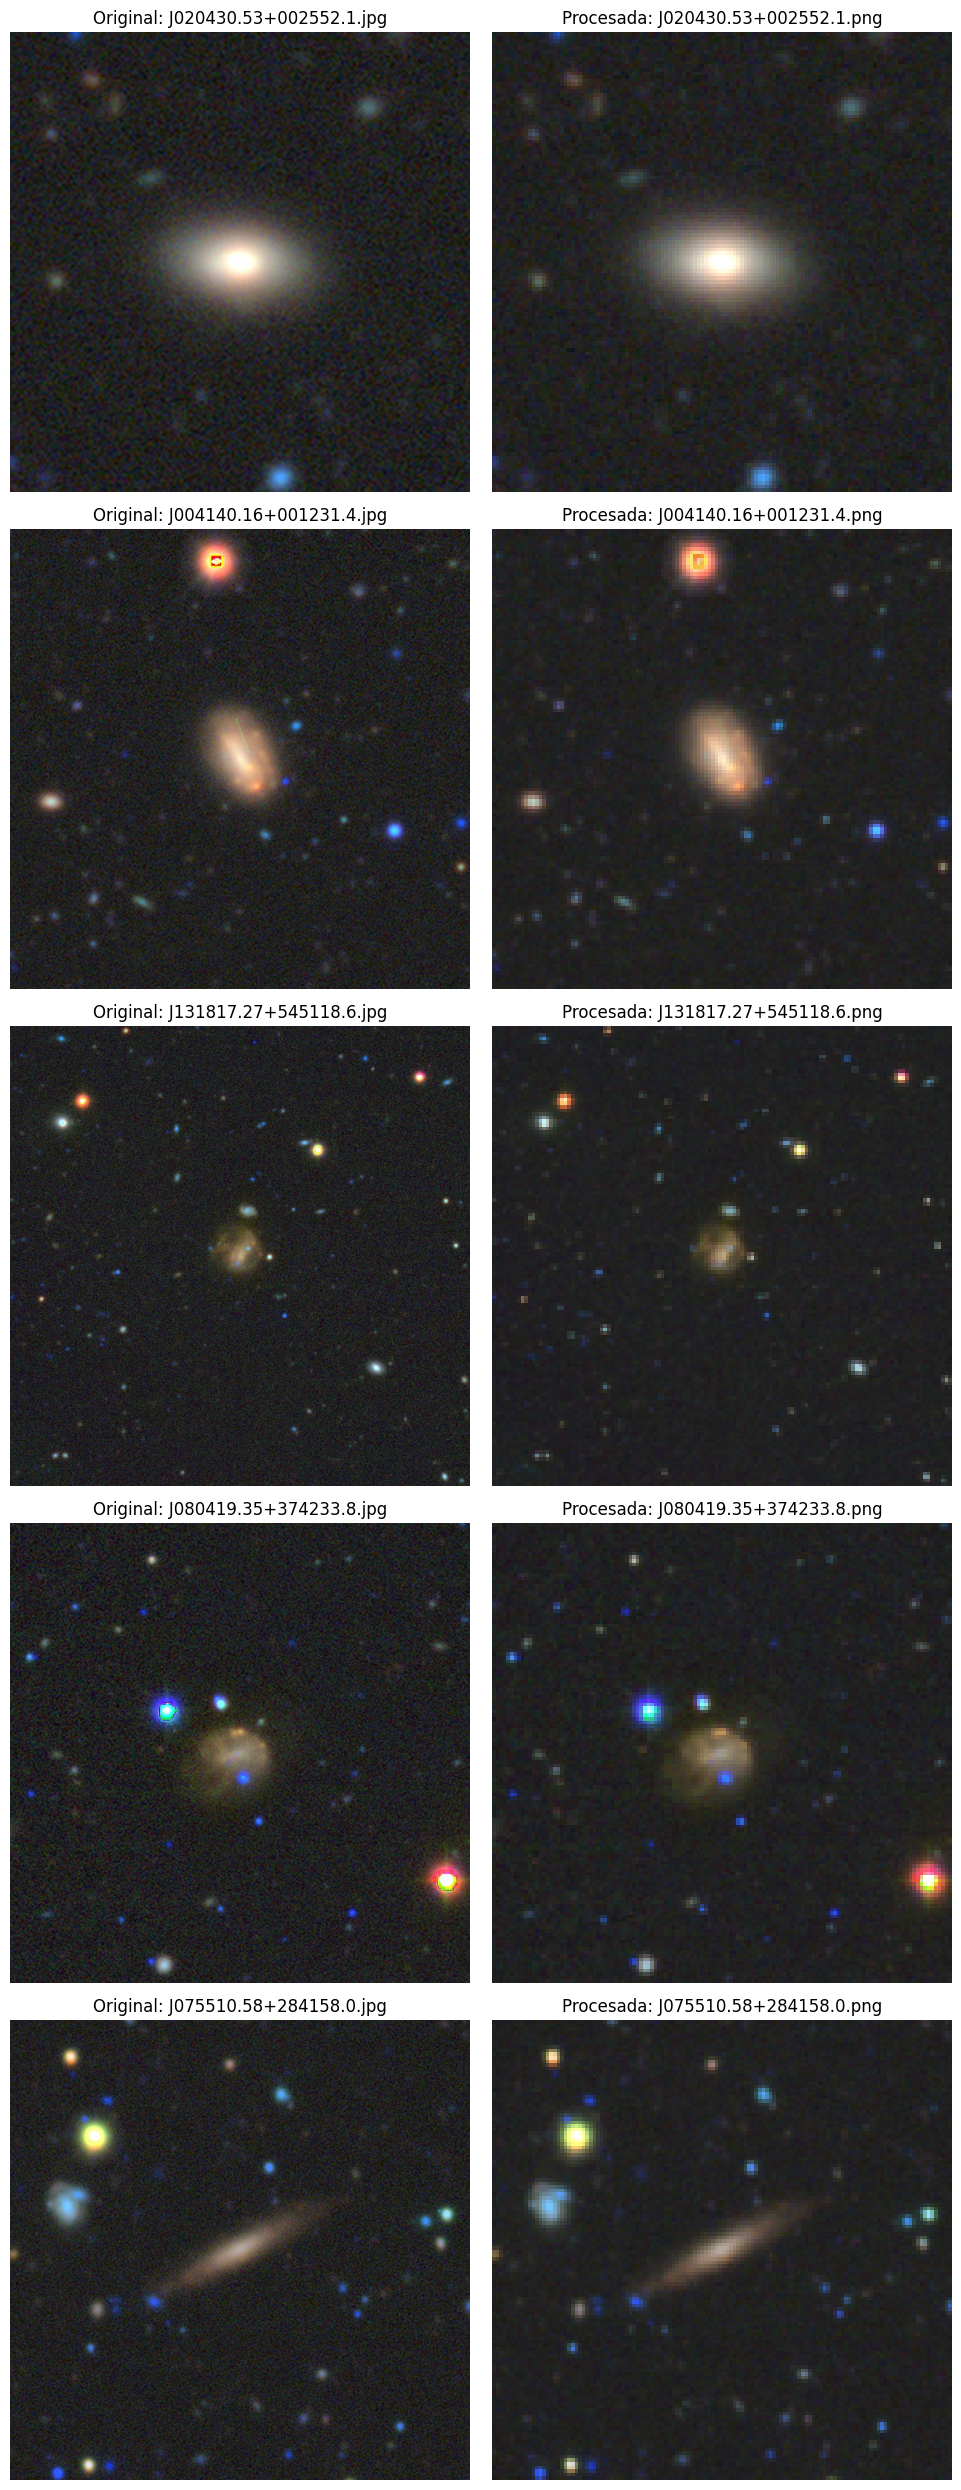

In [14]:
# Ejecutar comparación con 5 imágenes de enanas
compare_images(1.0, n=5, random_state=32)

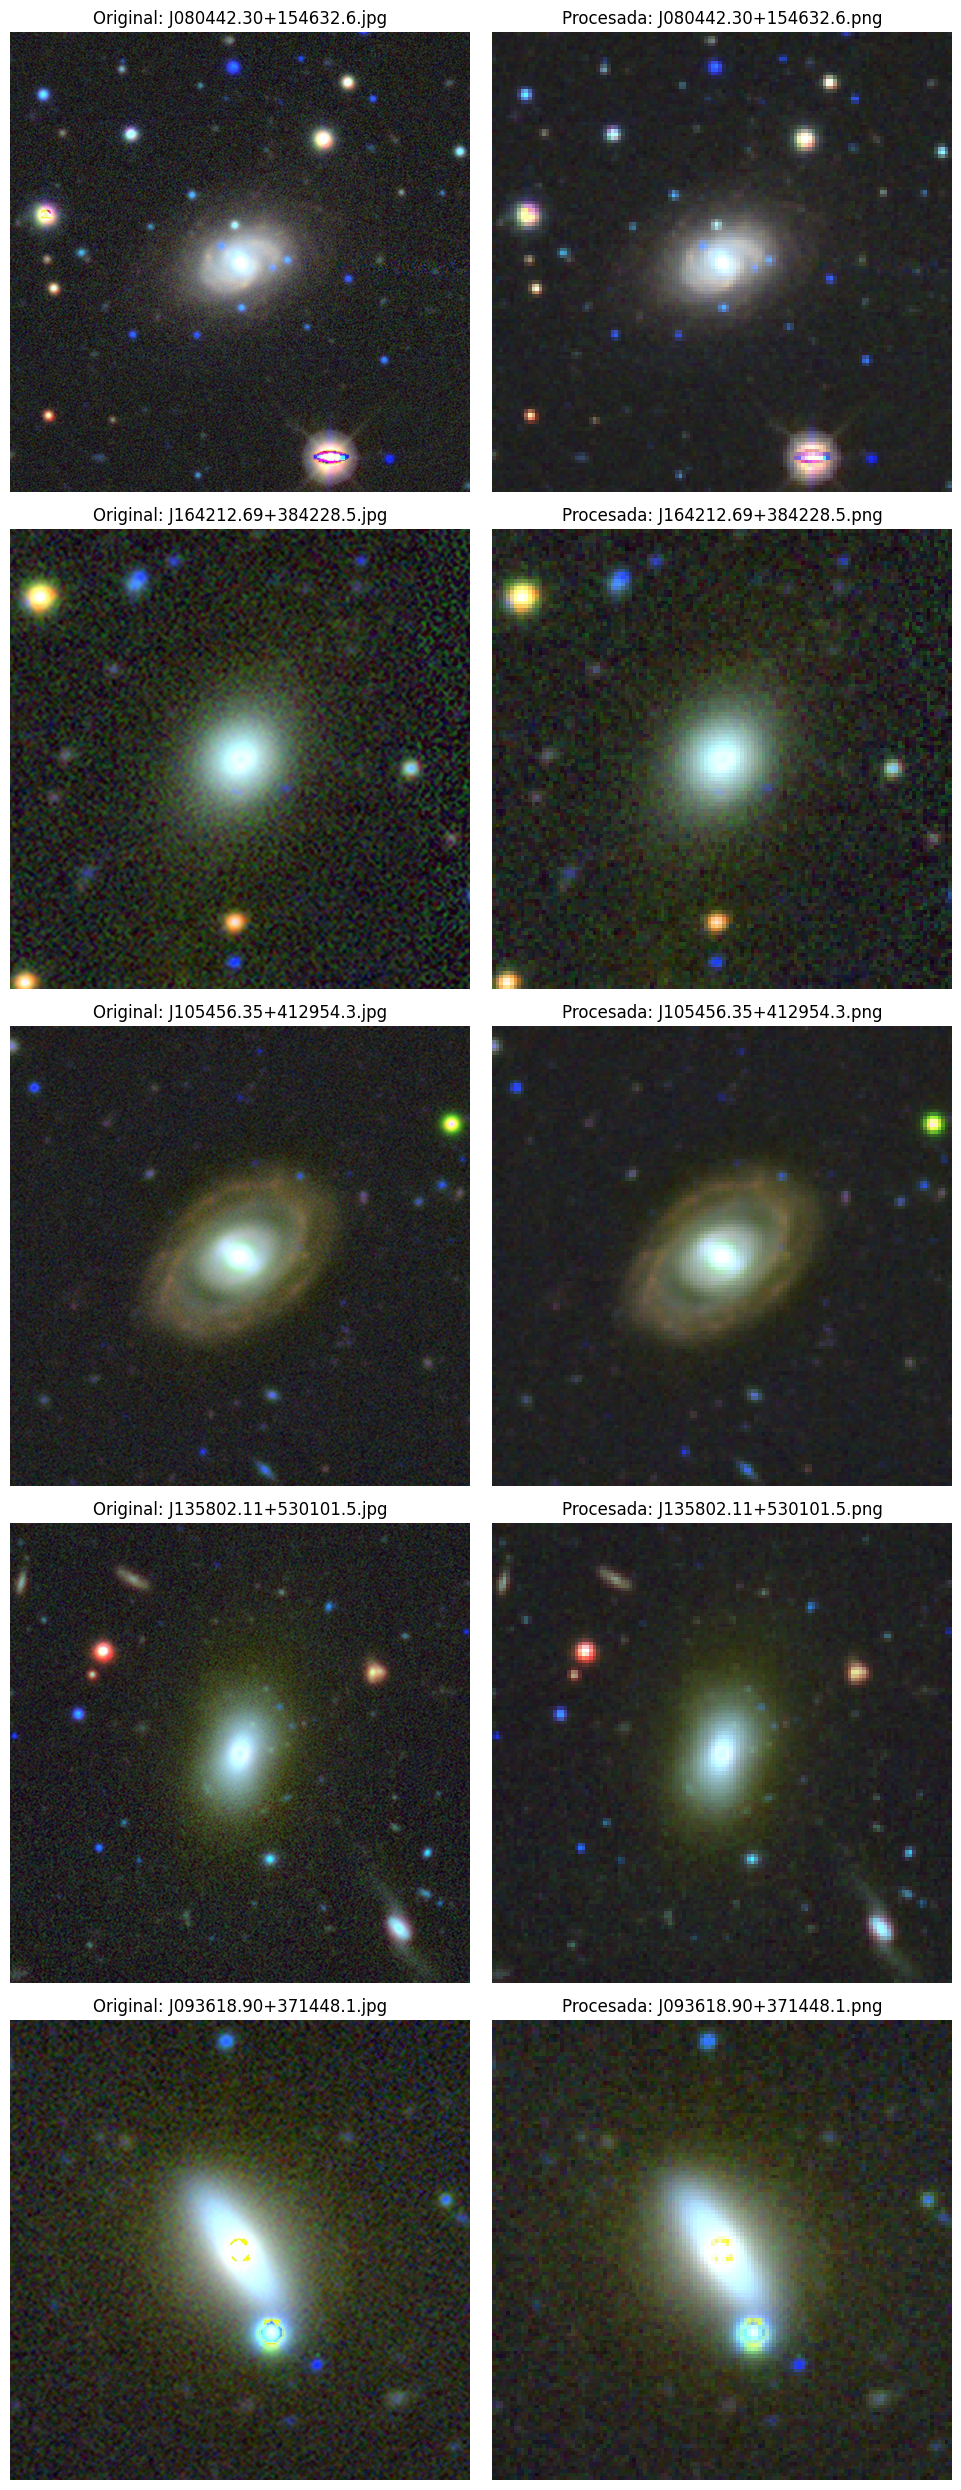

In [15]:
# Ejecutar comparación con 5 imágenes de no enanas
compare_images(0.0, n=5, random_state=2)

Se dividen las imagenes en datasets de train, test y val en folders separados

In [16]:
DATASETS_PATH = "..\\nair_manga\imagenes\datasets"
FOLDERS = {
    "train_dwarfs": os.path.join(DATASETS_PATH, "train/1_dwarfs"),
    "train_no_dwarfs": os.path.join(DATASETS_PATH, "train/0_no_dwarfs"),
    "val_dwarfs": os.path.join(DATASETS_PATH, "val/1_dwarfs"),
    "val_no_dwarfs": os.path.join(DATASETS_PATH, "val/0_no_dwarfs"),
    "test_dwarfs": os.path.join(DATASETS_PATH, "test/1_dwarfs"),
    "test_no_dwarfs": os.path.join(DATASETS_PATH, "test/0_no_dwarfs"),
}

## Modelo base

In [ ]:
def prepare_datasets(seed, batch_size, data_transforms, RATIO=3):
    # 📌 Crear carpetas
    for folder in FOLDERS.values():
        shutil.rmtree(folder, ignore_errors=True)
        os.makedirs(folder, exist_ok=True)
    
    # 📌 Leer DataFrame con etiquetas
    #data = pd.read_csv("dataset_labels.csv")  # Asegúrate de que el CSV existe y tiene 'img_name' y 'dwarf'
    original_dwarfs = data[data["dwarf"] == 1.0]
    original_no_dwarfs = data[data["dwarf"] == 0.0]

    # 📌 Submuestreo de la clase negativa
    num_dwarfs = len(original_dwarfs)
    num_no_dwarfs = int(num_dwarfs * RATIO)
    original_no_dwarfs = original_no_dwarfs.sample(n=min(num_no_dwarfs, len(original_no_dwarfs)), random_state=seed)

    # 📌 División de datos en train/val/test
    train_dwarfs, temp_dwarfs = train_test_split(original_dwarfs, test_size=0.3, stratify=original_dwarfs["dwarf"], random_state=seed)
    val_dwarfs, test_dwarfs = train_test_split(temp_dwarfs, test_size=1/3, stratify=temp_dwarfs["dwarf"], random_state=seed)
    train_no_dwarfs, temp_no_dwarfs = train_test_split(original_no_dwarfs, test_size=0.3, stratify=original_no_dwarfs["dwarf"], random_state=seed)
    val_no_dwarfs, test_no_dwarfs = train_test_split(temp_no_dwarfs, test_size=1/3, stratify=temp_no_dwarfs["dwarf"], random_state=seed)

    def move_images(image_set, dest_folder):
        for _, row in image_set.iterrows():
            img_name = os.path.splitext(row["img_name"])[0] + ".png"
            src_path = os.path.join(PREPROC_PATH, img_name)
            dst_path = os.path.join(dest_folder, img_name)
            shutil.copy(src_path, dst_path) if os.path.exists(src_path) else None

    move_images(train_dwarfs, FOLDERS["train_dwarfs"])
    move_images(val_dwarfs, FOLDERS["val_dwarfs"])
    move_images(test_dwarfs, FOLDERS["test_dwarfs"])
    move_images(train_no_dwarfs, FOLDERS["train_no_dwarfs"])
    move_images(val_no_dwarfs, FOLDERS["val_no_dwarfs"])
    move_images(test_no_dwarfs, FOLDERS["test_no_dwarfs"])

        # 📌 Cargar dataset con ImageFolder
    train_dataset = datasets.ImageFolder(root=os.path.join(DATASETS_PATH, "train"), transform=data_transforms)
    val_dataset = datasets.ImageFolder(root=os.path.join(DATASETS_PATH, "val"), transform=data_transforms)
    test_dataset = datasets.ImageFolder(root=os.path.join(DATASETS_PATH, "test"), transform=data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [57]:
def evaluate_model(model, test_loader, thres):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    test_correct, test_total = 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.float().to(device).view(-1, 1)
            outputs = model(images)

            # 🔥 Ajustamos el umbral de clasificación
            preds = (torch.sigmoid(outputs) > thres).float()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_acc = test_correct / test_total
    print(f"Test Accuracy: {test_acc:.4f}")

    # 📌 Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

    # Calcular métricas
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Mostrar resultados
    print(accuracy, precision, recall, f1)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Dwarfs", "Dwarfs"], yticklabels=["No Dwarfs", "Dwarfs"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión - Test")
    plt.show()

def train_model(modelType, train_params, seed, verbose=True):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # print(f"✅ Usando dispositivo: {device}")
    # model = model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0  # Contador para early stopping

    model=modelType(train_params)

    model, device, data_transforms, criterion, optimizer, scheduler, patience = model.get_components()

    train_loader, val_loader, test_loader = prepare_datasets(seed, train_params['batch_size'], data_transforms)

    for epoch in range(train_params['epochs']):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.float().to(device).view(-1, 1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > train_params['thres']).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # 📌 Evaluación en validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.float().to(device).view(-1, 1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) >  train_params['thres']).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        if verbose: print(f"Epoch {epoch+1}/{train_params['epochs']}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # 📌 Ajustar Learning Rate si no mejora
        scheduler.step(val_loss)
        if verbose: print(f"Nuevo Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        # 📌 Early Stopping si no mejora en `patience` épocas
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset paciencia
            best_model = model.state_dict()  # Guardar mejor modelo
        else:
            patience_counter += 1  # Incrementar paciencia

        if patience_counter >= patience:
            if verbose : print(f"⏹️ Early stopping activado en la época {epoch+1}")
            break  # Salir del bucle de entrenamiento

    # 📌 Cargar el mejor modelo antes del stopping
    model.load_state_dict(best_model)
    return model, test_loader

def cross_val_train(modelType, train_params, n_seeds=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#def cross_val_train(model, device, data_transforms, criterion, optimizer, scheduler, train_loader, val_loader, patience, epochs):
    # 📌 Lista de seeds para evaluar
    seeds = random.sample(range(1, 101), min(n_seeds,100))
    results = []
    models = {}


    for i, seed in enumerate(seeds):
        print(f"🚀 Evaluando con seed {i + 1}: {seed}")
        #train_loader, val_loader, test_loader = prepare_datasets(seed, RATIO, data_transforms)

        #model = train_model(model, device, criterion, optimizer, scheduler, train_loader, val_loader, patience, num_epochs, verbose=False)
        model, test_loader = train_model(modelType, train_params, seed, False)
        
        # 📌 Evaluación
        y_true, y_pred = [], []
        model.eval()
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.float().to(device).view(-1, 1)
                outputs = model(images)
                preds = (torch.sigmoid(outputs) > train_params['thres']).float()
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        cm = confusion_matrix(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        results.append([seed, acc, prec, rec, f1])
        print("Conf matrix:\n", cm)
        print(f"Acc: {acc} Prec: {prec} Rec: {rec} F1: {f1}")
        models[seed]=model

    
    
    res_df=pd.DataFrame(results, columns=["Seed", "Accuracy", "Precision", "Recall", "F1-score"])
    print(res_df.describe())
    # 📌 Visualizar resultados
    sns.boxplot(data=res_df.iloc[:, 1:])
    plt.show()
    return models


## convnext_tiny

In [60]:
convnext_train_params={
    'img_size' : 128
    ,'batch_size' : 16
    ,'learning_rate' : 2e-4  # Valor inicial de LR
    ,'epochs' : 20  # Número de épocas
    ,'thres' : 0.65  # Umbral de clasificación
    ,'patience' : 5 
}


In [ ]:

class ConvNextModel:
    def __init__(self, train_params):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")       
        self.patience = train_params['patience']
        self.img_size = train_params['img_size']
        self.learning_rate = train_params['learning_rate']
        self.data_transforms = self._get_transforms()
        self.model = self._build_model()
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(3.0).to(self.device))
        self.optimizer = optim.Adam(self.model.classifier.parameters(), lr=self.learning_rate)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', patience=self.patience, factor=0.5, min_lr=1e-6)
        
    def _get_transforms(self):
        return transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def _build_model(self):
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        
        # 🔹 Freeze all layers except the last ones
        for param in model.parameters():
            param.requires_grad = False
        
        # 📌 Modify the classifier for binary classification
        num_ftrs = model.classifier[2].in_features
        model.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.3),  # 🔥 Increased Dropout for overfitting prevention
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # 🔥 Another Dropout for more regularization
            nn.Linear(128, 1)  # Output layer
        )
        
        # 🔹 Initialize new layer weights
        for layer in model.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                layer.bias.data.fill_(0)
        
        # 🔹 Unfreeze the last 50 layers for fine-tuning
        for param in model.features[-50:].parameters():
            param.requires_grad = True
        
        return model.to(self.device)
    
    def get_components(self):
        return self.model, self.device, self.data_transforms, self.criterion, self.optimizer, self.scheduler, self.patience


In [61]:
#model, device, data_transforms, criterion, optimizer, scheduler = get_convNext_model()

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"✅ Usando dispositivo: {device}")

#model = model.to(device)

#convnext_model = ConvNextModel() 

seed=42

convnext_model, test_loader = train_model(ConvNextModel, convnext_train_params, seed)

Epoch 1/20, Train Loss: 1.0407, Train Acc: 0.7511, Val Loss: 1.0455, Val Acc: 0.7460
Nuevo Learning Rate: 0.000200
Epoch 2/20, Train Loss: 1.0142, Train Acc: 0.7511, Val Loss: 1.0199, Val Acc: 0.7460
Nuevo Learning Rate: 0.000200
Epoch 3/20, Train Loss: 0.9888, Train Acc: 0.7511, Val Loss: 0.9983, Val Acc: 0.7460
Nuevo Learning Rate: 0.000200
Epoch 4/20, Train Loss: 0.9397, Train Acc: 0.7626, Val Loss: 0.9735, Val Acc: 0.7540
Nuevo Learning Rate: 0.000200
Epoch 5/20, Train Loss: 0.8891, Train Acc: 0.7717, Val Loss: 0.9529, Val Acc: 0.7540
Nuevo Learning Rate: 0.000200
Epoch 6/20, Train Loss: 0.8877, Train Acc: 0.7717, Val Loss: 0.9215, Val Acc: 0.7619
Nuevo Learning Rate: 0.000200
Epoch 7/20, Train Loss: 0.8580, Train Acc: 0.7831, Val Loss: 0.9020, Val Acc: 0.7778
Nuevo Learning Rate: 0.000200
Epoch 8/20, Train Loss: 0.8273, Train Acc: 0.8037, Val Loss: 0.8933, Val Acc: 0.7619
Nuevo Learning Rate: 0.000200
Epoch 9/20, Train Loss: 0.8261, Train Acc: 0.8105, Val Loss: 0.8840, Val Acc: 0.

Test Accuracy: 0.8438
[[42  6]
 [ 4 12]]
0.84375 0.6666666666666666 0.75 0.7058823529411765


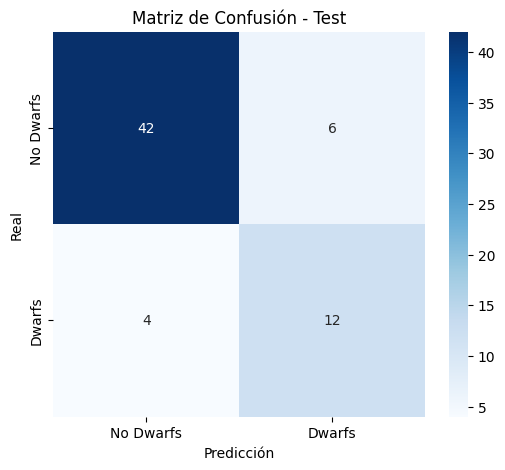

In [55]:
evaluate_model(convnext_model, test_loader, convnext_train_params['thres'])

🚀 Evaluando con seed 1: 41
Conf matrix:
 [[43  5]
 [ 7  9]]
Acc: 0.8125 Prec: 0.6428571428571429 Rec: 0.5625 F1: 0.6
🚀 Evaluando con seed 2: 89
Conf matrix:
 [[43  5]
 [ 9  7]]
Acc: 0.78125 Prec: 0.5833333333333334 Rec: 0.4375 F1: 0.5
🚀 Evaluando con seed 3: 20
Conf matrix:
 [[43  5]
 [ 6 10]]
Acc: 0.828125 Prec: 0.6666666666666666 Rec: 0.625 F1: 0.6451612903225806
🚀 Evaluando con seed 4: 15
Conf matrix:
 [[42  6]
 [ 7  9]]
Acc: 0.796875 Prec: 0.6 Rec: 0.5625 F1: 0.5806451612903226
🚀 Evaluando con seed 5: 5
Conf matrix:
 [[36 12]
 [ 7  9]]
Acc: 0.703125 Prec: 0.42857142857142855 Rec: 0.5625 F1: 0.4864864864864865
🚀 Evaluando con seed 6: 87
Conf matrix:
 [[43  5]
 [10  6]]
Acc: 0.765625 Prec: 0.5454545454545454 Rec: 0.375 F1: 0.4444444444444444
🚀 Evaluando con seed 7: 66
Conf matrix:
 [[39  9]
 [ 5 11]]
Acc: 0.78125 Prec: 0.55 Rec: 0.6875 F1: 0.6111111111111112
🚀 Evaluando con seed 8: 83
Conf matrix:
 [[43  5]
 [ 3 13]]
Acc: 0.875 Prec: 0.7222222222222222 Rec: 0.8125 F1: 0.7647058823529

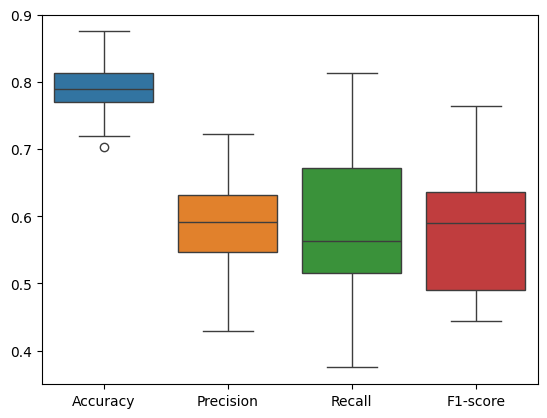

In [62]:
convnext_models = cross_val_train(ConvNextModel, convnext_train_params, 10)

## resnet50

In [71]:
resnet50_train_params={
    'img_size' : 128
    ,'batch_size' : 64
    ,'learning_rate' : 5e-3  # Valor inicial de LR
    ,'epochs' : 15  # Número de épocas
    ,'thres' : 0.5  # Umbral de clasificación
    ,'patience' : 3
}

In [64]:
class ResNet50Model:
    def __init__(self, train_params):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")       
        self.patience = train_params['patience']
        self.img_size = train_params['img_size']
        self.learning_rate = train_params['learning_rate']
        self.data_transforms = self._get_transforms()
        self.model = self._build_model()
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(0.6).to(self.device))
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', patience=self.patience, factor=0.5, min_lr=1e-6)
        
    def _get_transforms(self):
        return transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def _build_model(self):
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 1)
        
        # 🔹 Freeze all layers except the last ones
        for param in model.parameters():
            param.requires_grad = False
        
        # 🔹 Initialize new layer weights
        for layer in model.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                layer.bias.data.fill_(0)
        
        # 🔹 Unfreeze the last 50 layers for fine-tuning
        for param in list(model.parameters())[-100:]:
            param.requires_grad = True
        
        return model.to(self.device)
    
    def get_components(self):
        return self.model, self.device, self.data_transforms, self.criterion, self.optimizer, self.scheduler, self.patience


Epoch 1/15, Train Loss: 0.5498, Train Acc: 0.7260, Val Loss: 14.2281, Val Acc: 0.2540
Nuevo Learning Rate: 0.005000
Epoch 2/15, Train Loss: 0.2744, Train Acc: 0.8151, Val Loss: 60.6584, Val Acc: 0.2540
Nuevo Learning Rate: 0.005000
Epoch 3/15, Train Loss: 0.1951, Train Acc: 0.8973, Val Loss: 11.8987, Val Acc: 0.2143
Nuevo Learning Rate: 0.005000
Epoch 4/15, Train Loss: 0.1617, Train Acc: 0.9201, Val Loss: 0.3380, Val Acc: 0.7857
Nuevo Learning Rate: 0.005000
Epoch 5/15, Train Loss: 0.1055, Train Acc: 0.9384, Val Loss: 0.4099, Val Acc: 0.8333
Nuevo Learning Rate: 0.005000
Epoch 6/15, Train Loss: 0.0800, Train Acc: 0.9680, Val Loss: 0.5661, Val Acc: 0.8571
Nuevo Learning Rate: 0.005000
Epoch 7/15, Train Loss: 0.0349, Train Acc: 0.9795, Val Loss: 0.6134, Val Acc: 0.8492
Nuevo Learning Rate: 0.005000
⏹️ Early stopping activado en la época 7
Test Accuracy: 0.8750
[[42  6]
 [ 2 14]]
0.875 0.7 0.875 0.7777777777777777


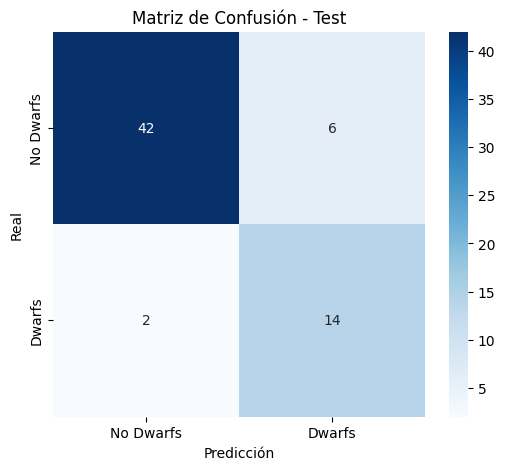

In [72]:
seed=42

resnet50_model, test_loader = train_model(ResNet50Model, resnet50_train_params, seed)
evaluate_model(resnet50_model, test_loader, resnet50_train_params['thres'])

Test Accuracy: 0.8750
[[41  7]
 [ 1 15]]
0.875 0.6818181818181818 0.9375 0.7894736842105263


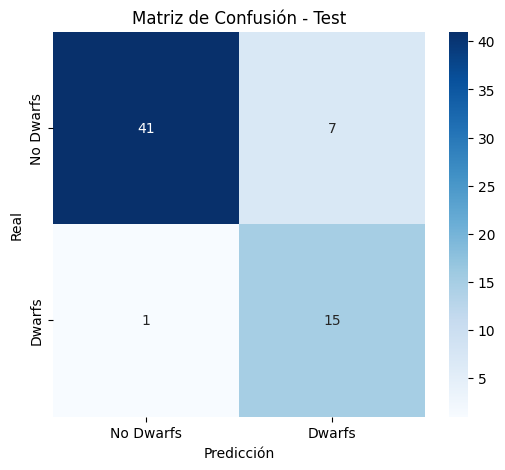

In [333]:
evaluate_model(resnet50_model, test_loader, 0.5)

🚀 Evaluando con seed 1: 24
Conf matrix:
 [[43  5]
 [ 8  8]]
Acc: 0.796875 Prec: 0.6153846153846154 Rec: 0.5 F1: 0.5517241379310345
🚀 Evaluando con seed 2: 27
Conf matrix:
 [[45  3]
 [ 4 12]]
Acc: 0.890625 Prec: 0.8 Rec: 0.75 F1: 0.7741935483870968
🚀 Evaluando con seed 3: 79
Conf matrix:
 [[45  3]
 [ 5 11]]
Acc: 0.875 Prec: 0.7857142857142857 Rec: 0.6875 F1: 0.7333333333333333
🚀 Evaluando con seed 4: 14
Conf matrix:
 [[47  1]
 [ 8  8]]
Acc: 0.859375 Prec: 0.8888888888888888 Rec: 0.5 F1: 0.64
🚀 Evaluando con seed 5: 54
Conf matrix:
 [[40  8]
 [ 3 13]]
Acc: 0.828125 Prec: 0.6190476190476191 Rec: 0.8125 F1: 0.7027027027027027
🚀 Evaluando con seed 6: 39
Conf matrix:
 [[44  4]
 [ 2 14]]
Acc: 0.90625 Prec: 0.7777777777777778 Rec: 0.875 F1: 0.8235294117647058
🚀 Evaluando con seed 7: 41
Conf matrix:
 [[46  2]
 [ 4 12]]
Acc: 0.90625 Prec: 0.8571428571428571 Rec: 0.75 F1: 0.8
🚀 Evaluando con seed 8: 1
Conf matrix:
 [[43  5]
 [ 6 10]]
Acc: 0.828125 Prec: 0.6666666666666666 Rec: 0.625 F1: 0.6451612

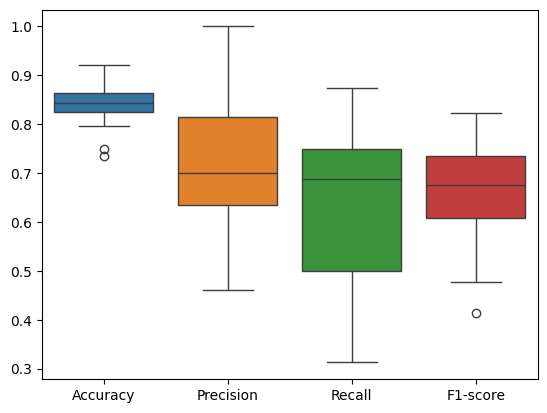

In [73]:
resnet50_models = cross_val_train(ResNet50Model, resnet50_train_params, 20)

Epoch 1/15, Train Loss: 0.5654, Train Acc: 0.7306, Val Loss: 17034.6973, Val Acc: 0.7460
Nuevo Learning Rate: 0.005000
Epoch 2/15, Train Loss: 0.7988, Train Acc: 0.7489, Val Loss: 1394.1628, Val Acc: 0.4127
Nuevo Learning Rate: 0.005000
Epoch 3/15, Train Loss: 0.3917, Train Acc: 0.7329, Val Loss: 1.7700, Val Acc: 0.7063
Nuevo Learning Rate: 0.005000
Epoch 4/15, Train Loss: 0.2705, Train Acc: 0.7511, Val Loss: 0.6103, Val Acc: 0.7302
Nuevo Learning Rate: 0.005000
Epoch 5/15, Train Loss: 0.2257, Train Acc: 0.7603, Val Loss: 0.3960, Val Acc: 0.7460
Nuevo Learning Rate: 0.005000
Epoch 6/15, Train Loss: 0.2223, Train Acc: 0.8014, Val Loss: 0.4334, Val Acc: 0.8254
Nuevo Learning Rate: 0.005000
Epoch 7/15, Train Loss: 0.1779, Train Acc: 0.8676, Val Loss: 0.3250, Val Acc: 0.8175
Nuevo Learning Rate: 0.005000
Epoch 8/15, Train Loss: 0.1717, Train Acc: 0.9110, Val Loss: 0.3983, Val Acc: 0.8730
Nuevo Learning Rate: 0.005000
Epoch 9/15, Train Loss: 0.1409, Train Acc: 0.9452, Val Loss: 0.2611, Val 

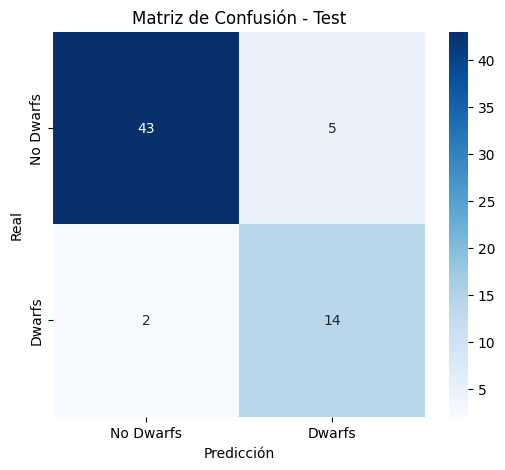

In [116]:
seed=11

resnet50_model, test_loader = train_model(ResNet50Model, resnet50_train_params, seed)

evaluate_model(resnet50_model, test_loader, resnet50_train_params['thres'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   



In [117]:
def evaluate_and_display(model, test_loader, thresh, device="cuda"):
    """
    Collects images, labels, and predictions from a test DataLoader,
    then displays a grid of images categorized into TP, FN, FP, TN.

    Args:
        model (torch.nn.Module): Trained model.
        test_loader (torch.utils.data.DataLoader): DataLoader for test set.
        device (str): Device to run inference on ("cuda" or "cpu").
    """
    model.to(device)
    model.eval()  # Set model to evaluation mode

    images_list = []
    labels_list = []
    preds_list = []

    # Step 1: Collect test results
    with torch.no_grad():  # Disable gradient calculation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Get model predictions
            outputs = model(images)
            preds = torch.sigmoid(outputs)  # Convert logits to probabilities
            preds = (preds > thresh).int()  # Convert to binary predictions (0 or 1)
            print(thresh)

            # Convert to CPU and store results (as individual items)
            for img, label, pred in zip(images.cpu(), labels.cpu(), preds.cpu()):
                images_list.append(img.numpy())   # Store each image separately
                labels_list.append(label.item())  # Convert tensor to scalar
                preds_list.append(pred.item())    # Convert tensor to scalar

    # Convert lists to NumPy arrays
    images = np.array(images_list)
    labels = np.array(labels_list)
    preds = np.array(preds_list)

    # Step 2: Categorize images into TP, FN, FP, TN
    tp_indices = np.where((labels == 1) & (preds == 1))[0]
    fn_indices = np.where((labels == 1) & (preds == 0))[0]
    fp_indices = np.where((labels == 0) & (preds == 1))[0]
    tn_indices = np.where((labels == 0) & (preds == 0))[0]

    # Select up to 5 images per category
    def get_sample(indices, num=5):
        return indices[:num] if len(indices) >= num else indices

    tp_sample = get_sample(tp_indices)
    fn_sample = get_sample(fn_indices)
    fp_sample = get_sample(fp_indices)
    tn_sample = get_sample(tn_indices)

    # Step 3: Display the images in a 4x5 grid
    fig, axes = plt.subplots(4, 5, figsize=(12, 10))
    fig.suptitle("Classification Results: TP, FN, FP, TN", fontsize=16)

    # List of categories and their samples
    categories = [("TP", tp_sample), ("FN", fn_sample), ("FP", fp_sample), ("TN", tn_sample)]

    # Iterate over rows (categories) and columns (5 images per row)
    for row, (label, indices) in enumerate(categories):
        for col in range(5):
            ax = axes[row, col]
            if col < len(indices):
                img_idx = indices[col]

                # Convert from (C, H, W) -> (H, W, C) for RGB images
                img = np.transpose(images[img_idx], (1, 2, 0)) if images.shape[1] == 3 else images[img_idx].squeeze()

                ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
                ax.set_title(label)
                ax.axis("off")
            else:
                ax.axis("off")  # Hide extra plots if not enough images

    row_labels = ["True Positives (TP)", "False Negatives (FN)", "False Positives (FP)", "True Negatives (TN)"]
    for ax, label in zip(axes[:, 0], row_labels):
        ax.set_ylabel(label, rotation=90, size=12, labelpad=20)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
    plt.show()


0.5


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.64].
Clipping input data 

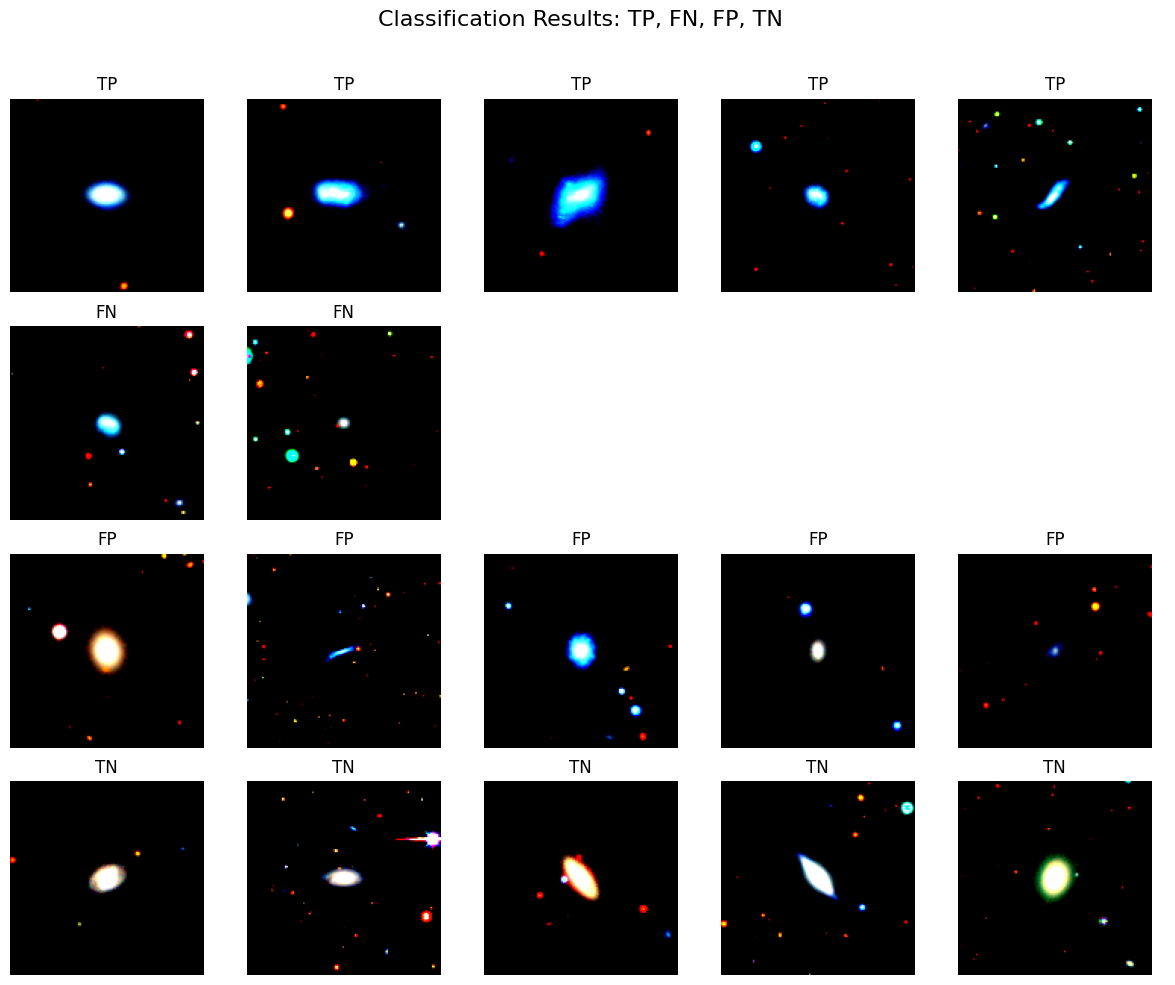

In [118]:
evaluate_and_display(resnet50_model, test_loader, resnet50_train_params['thres'])